In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import sxs

In [3]:
catalog = sxs.load('simulations')

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.


  0%|          | 0/5589954 [00:00<?, ?it/s]

In [4]:
print("SXS:BBH:1156" in catalog)

True


In [7]:
sim = sxs.load("SXS:BBH:1156")

In [12]:
sxs.utilities.lvcnr.conversion.convert_simulation('/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1156',
                                                  '/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1156_l2m2',
                                                  waveform_name='Strain_N2.h5',
                                                  resolution=3,
                                                  modes='22only')

sxs.utilities.lvcnr.convert_simulation(
    sxs_data_path='/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1156',
    out_path='/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1156_l2m2',
    truncation_time=None,
    resolution=3,
    modes='22only',
    tolerance=1e-06,
    quiet=False
)
Starting at 12:40PM EDT on Jun 24, 2026
Converting SXS:BBH:1156
Extrapolation order: Extrapolated_N2
Output filename is '/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1156_l2m2/SXS_BBH_1156_Res3.h5'
Computing ['mass1-vs-time']
Computing ['mass2-vs-time']
Computing ['remnant-mass-vs-time']
Computing ['spin1x-vs-time', 'spin1y-vs-time', 'spin1z-vs-time']
Computing ['spin2x-vs-time', 'spin2y-vs-time', 'spin2z-vs-time']
Computing ['remnant-spinx-vs-time', 'remnant-spiny-vs-time', 'remnant-spinz-vs-time']
Computing ['position1x-vs-time', 'position1y-vs-time', 'position1z-vs-time']
Computing ['position2x-vs-time', 'position2y-vs-time', 'position2z-vs-time']
Computing ['remnant-positionx-vs-time', 'rem

  0%|          | 0/6597437 [00:00<?, ?it/s]

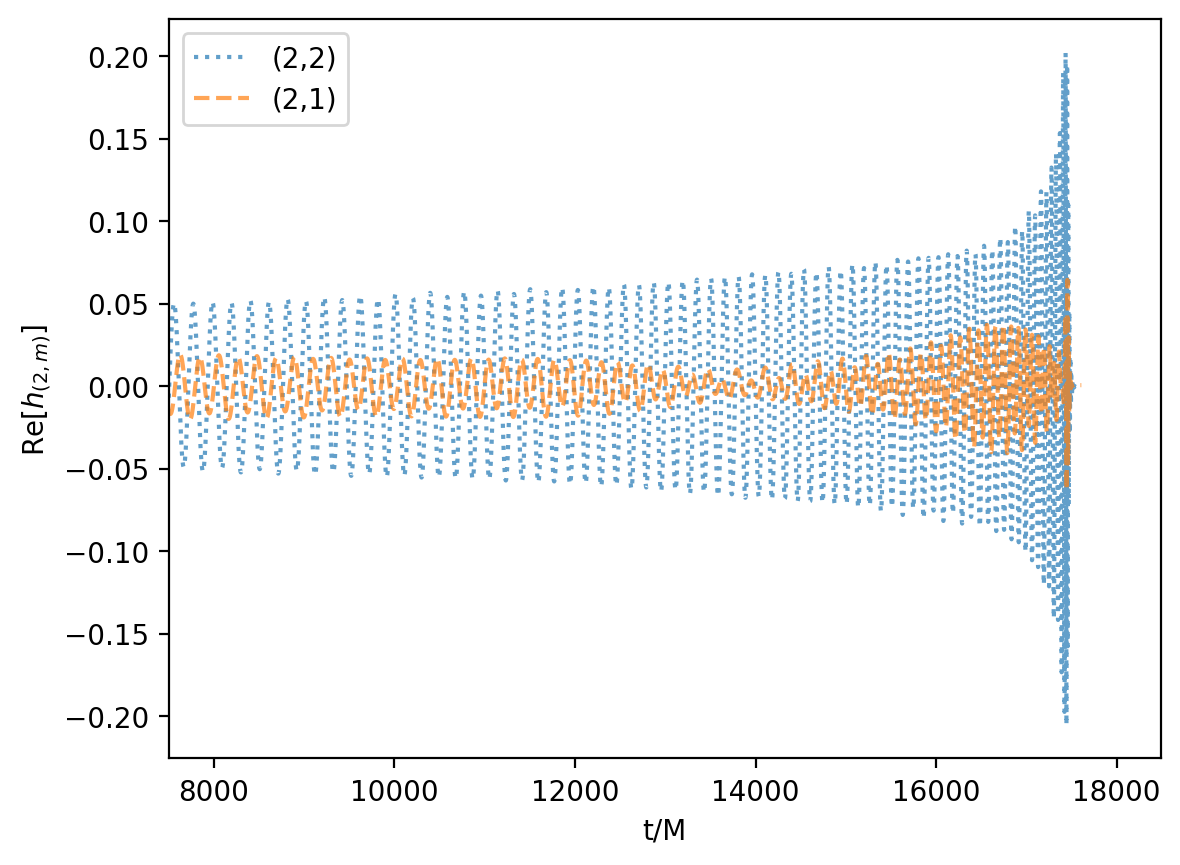

In [8]:
h = sim.h

# Check the (2,0) mode — should show a non-oscillatory step across merger
# h20 = h[:, h.index(2, 0)]
h21 = h[:, h.index(2, 1)]
h22 = h[:, h.index(2, 2)]
import matplotlib.pyplot as plt

plt.plot(h.t, h22.real, ls=':', alpha=0.7, label='(2,2)')
plt.plot(h.t, h21.real, ls='--', alpha=0.7, label='(2,1)')
# plt.plot(h.t, h20.real, alpha=0.8, label='(2,0)')

plt.xlim(7500)
plt.xlabel("t/M")
plt.ylabel("Re[$h_{(2,m)}$]")
# plt.title("Memory mode (2,0)")
plt.legend()

In [15]:
sxs.utilities.lvcnr.conversion.convert_simulation?

Signature:
sxs.utilities.lvcnr.conversion.convert_simulation(
    sxs_data_path,
    out_path,
    waveform_name=None,
    out_waveform_name=None,
    truncation_time=None,
    resolution=None,
    modes=8,
    tolerance=1e-06,
    quiet=False,
)
Docstring:
Convert a simulation from the SXS BBH catalog into the LVC format.

This function outputs a file in LVC format named SXS_BBH_####_Res#.h5 in
out_path.

Note that this function is essentially a wrapper for
`SimulationConverter.convert`.  If you have very many systems to convert, it is
significantly faster to create the SimulationConverter object once, and then
call the `convert` method for each system.

Parameters
----------
sxs_data_path : string
    Path to directory containing waveform file,
    Horizons.h5, and metadata.txt or metadata.json files.
out_path : string
    Path where LVC-format file is to be output
waveform_name : string
    Name of waveform to load in sxs_data_path. If not specified,
    will try to load Strain_N2.h

In [7]:
type(sim.h)

sxs.waveforms.waveform_modes.WaveformModes